# Real and Fake Face detection
In this replository is a small application that uses a CNN to predict real or fake face.

Data has been collected from kaggle. For training ~1450 images and with an additional ~300 images for validation.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Flatten, Dense, MaxPooling2D
from tensorflow.keras.preprocessing import image
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [ ]:
try:
    from tensorflow.python.util import module_wrapper as deprecation
except ImportError:
    from tensorflow.python.util import deprecation_wrapper as deprecation
deprecation._PER_MODULE_WARNING_LIMIT = 0

# Dataset

kera's ImageDataGenerator dataset is used to label the data from the directories but also to slightly augment the data with shifts, rotations, zooms, and mirroring. Mirroring will help to ensure that the data are not biased to a particular handedness.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Check what's inside the real-and-fake-face-detection-master folder
!ls "/content/drive/MyDrive/real-and-fake-face-detection-master"

dataset  model_checkpoint.hdf5	model_checkpoint.keras	model.ipynb  README.md


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define batch size
nbatch = 128

# Create data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10.,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True)

test_datagen = ImageDataGenerator(rescale = 1./255)

# Path to your dataset in Google Drive
drive_path = '/content/drive/MyDrive/real-and-fake-face-detection-master/dataset'

# Load training data
training_set = train_datagen.flow_from_directory(
    f'{drive_path}/training',
    target_size=(128, 128),
    batch_size=nbatch,
    class_mode='binary')

# Load test data
test_set = test_datagen.flow_from_directory(
    f'{drive_path}/test',
    target_size=(128, 128),
    batch_size=nbatch,
    class_mode='binary')

print("Training set class indices:", training_set.class_indices)
print("Test set class indices:", test_set.class_indices)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 1437 images belonging to 2 classes.
Found 604 images belonging to 2 classes.
Training set class indices: {'fake': 0, 'real': 1}
Test set class indices: {'fake': 0, 'real': 1}


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define batch size
nbatch = 128

# Create data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10.,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True)

test_datagen = ImageDataGenerator(rescale = 1./255)

# Use the full path to your dataset in Google Drive
drive_path = '/content/drive/MyDrive/real-and-fake-face-detection-master/dataset'

# Load training data
training_set = train_datagen.flow_from_directory(
    f'{drive_path}/training',  # Use the full path
    target_size=(128, 128),
    batch_size=nbatch,
    class_mode='binary')

# Load test data
test_set = test_datagen.flow_from_directory(
    f'{drive_path}/test',  # Use the full path
    target_size=(128, 128),
    batch_size=nbatch,
    class_mode='binary')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 1437 images belonging to 2 classes.
Found 604 images belonging to 2 classes.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 1437 images belonging to 2 classes.
Found 604 images belonging to 2 classes.


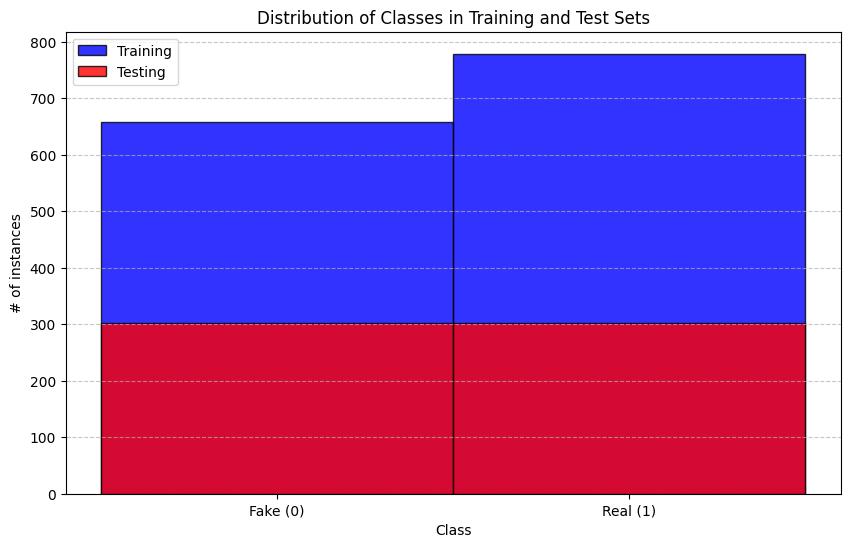

In [ ]:
# Import necessary libraries
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define batch size
nbatch = 128

# Create data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10.,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True)

test_datagen = ImageDataGenerator(rescale = 1./255)

# Use the full path to your dataset in Google Drive
drive_path = '/content/drive/MyDrive/real-and-fake-face-detection-master/dataset'

# Load training data
training_set = train_datagen.flow_from_directory(
    f'{drive_path}/training',
    target_size=(128, 128),
    batch_size=nbatch,
    class_mode='binary')

# Load test data
test_set = test_datagen.flow_from_directory(
    f'{drive_path}/test',
    target_size=(128, 128),
    batch_size=nbatch,
    class_mode='binary')

# Now create the histogram
plt.figure(figsize=(10, 6))
h1 = plt.hist(training_set.classes, bins=range(0,3), alpha=0.8, color='blue', edgecolor='black', label='Training')
h2 = plt.hist(test_set.classes, bins=range(0,3), alpha=0.8, color='red', edgecolor='black', label='Testing')
plt.ylabel('# of instances')
plt.xlabel('Class')
plt.title('Distribution of Classes in Training and Test Sets')
plt.xticks([0.5, 1.5], ['Fake (0)', 'Real (1)'])
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Found 1437 images belonging to 2 classes.
(128, 128, 128, 3) (128,)


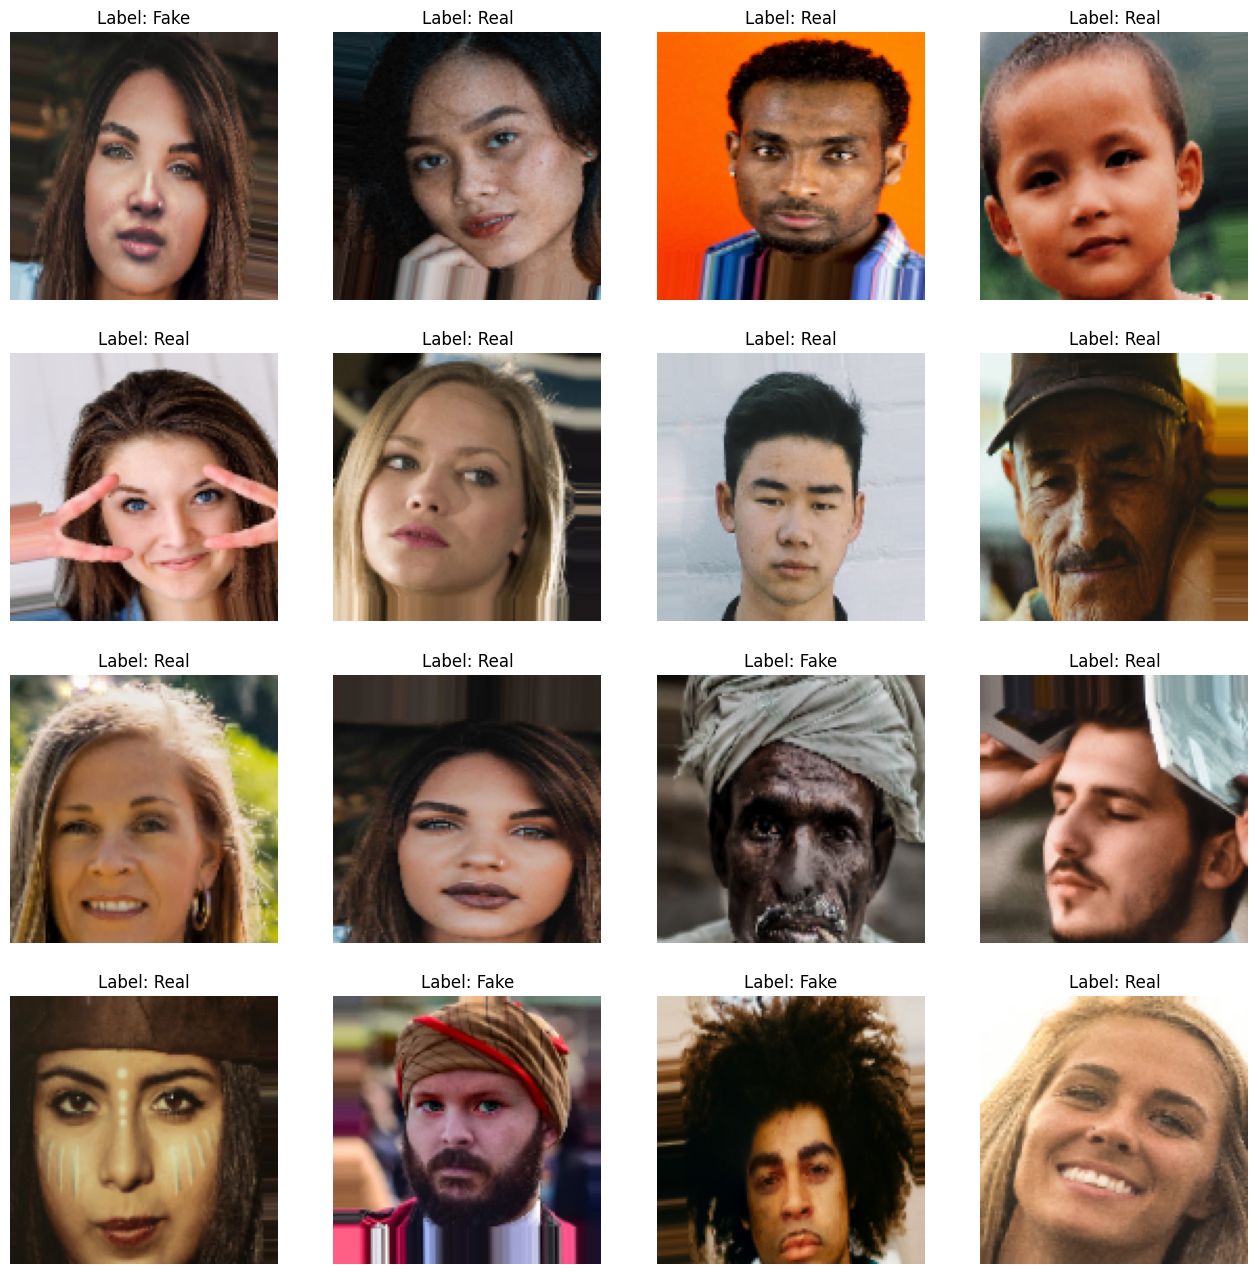

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Use the data generators you already defined
# If you need to redefine them:
nbatch = 128
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10.,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True)

drive_path = '/content/drive/MyDrive/real-and-fake-face-detection-master/dataset'
training_set = train_datagen.flow_from_directory(
    f'{drive_path}/training',
    target_size=(128, 128),
    batch_size=nbatch,
    class_mode='binary')

# Now visualize some samples
for X, y in training_set:
    print(X.shape, y.shape)
    plt.figure(figsize=(16, 16))
    for i in range(16):
        plt.subplot(4, 4, i+1)
        plt.axis('off')
        # Display the label (0 = fake, 1 = real)
        plt.title(f'Label: {"Real" if y[i] > 0.5 else "Fake"}')

        # Display the image (all channels, not just channel 0)
        # The images are RGB, so we should display them in color
        img = np.uint8(255 * X[i])
        plt.imshow(img)
    break

# Convolutional Neural Network model


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten

model = Sequential()

model.add(Conv2D(32, kernel_size=(3, 3),
                 activation='relu',
                 input_shape=(128,128,3)))

model.add(MaxPooling2D(pool_size=(2,2)))  # Corrected from MaxPool2D to MaxPooling2D

model.add(Conv2D(64, kernel_size=(3, 3),
                 activation='relu'))

model.add(MaxPooling2D(pool_size=(2,2)))  # Corrected from MaxPool2D to MaxPooling2D

model.add(Conv2D(128, kernel_size=(3, 3),
                 activation='relu'))

model.add(MaxPooling2D(pool_size=(2,2)))  # Corrected from MaxPool2D to MaxPooling2D

model.add(Flatten())

model.add(Dense(activation="relu",
                units=256))

model.add(Dense(activation="sigmoid",
                units=1))

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       6,422,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,516,289 (24.86 MB)

 Trainable params: 6,516,289 (24.86 MB)

 Non-trainable params: 0 (0.00 B)

##### Compile the model

In [ ]:
model.compile(optimizer = 'adam',
              loss = 'binary_crossentropy',
              metrics = ['accuracy'])

# Training


In [ ]:
callbacks_list = [
    EarlyStopping(monitor='val_loss', patience=10),
    ModelCheckpoint(filepath='model_checkpoint.hdf5', monitor='val_loss', save_best_only=True, mode ='max'),
]

ValueError: The filepath provided must end in `.keras` (Keras model format). Received: filepath=model_checkpoint.hdf5

In [ ]:
# First, make sure to import the necessary libraries
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Then update the callbacks
callbacks_list = [
    EarlyStopping(monitor='val_loss', patience=10),
    ModelCheckpoint(filepath='model_checkpoint.keras', monitor='val_loss', save_best_only=True, mode='max'),
]

In [ ]:
callbacks_list = [
    EarlyStopping(monitor='val_loss', patience=10),
    ModelCheckpoint(
        filepath='/content/drive/MyDrive/real-and-fake-face-detection-master/model_checkpoint.keras',
        monitor='val_loss',
        save_best_only=True,
        mode='max'
    ),
]

In [ ]:
callbacks_list = [
    EarlyStopping(monitor='val_loss', patience=10),
    ModelCheckpoint(
        filepath='/content/drive/MyDrive/real-and-fake-face-detection-master/model_checkpoint.keras',
        monitor='val_loss',
        save_best_only=True,
        mode='min'  # Changed from 'max' to 'min'
    ),
]

In [ ]:
history = model.fit(
        training_set,
        steps_per_epoch=80,
        epochs=10,
        validation_data=test_set,
        validation_steps=28,
        callbacks = callbacks_list
    )

Epoch 1/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 83s 927ms/step - accuracy: 0.5616 - loss: 0.6803 - val_accuracy: 0.5364 - val_loss: 0.6924
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 79s 898ms/step - accuracy: 0.5254 - loss: 0.6889 - val_accuracy: 0.5116 - val_loss: 0.6894
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 80s 881ms/step - accuracy: 0.5587 - loss: 0.6797 - val_accuracy: 0.5563 - val_loss: 0.6856
Epoch 4/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 89s 974ms/step - accuracy: 0.5752 - loss: 0.6736 - val_accuracy: 0.5695 - val_loss: 0.6925
Epoch 5/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 143s 970ms/step - accuracy: 0.5754 - loss: 0.6761 - val_accuracy: 0.5447 - val_loss: 0.6900
Epoch 6/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 77s 855ms/step - accuracy: 0.5486 - loss: 0.6884 - val_accuracy: 0.4983 - val_loss: 0.6915
Epoch 7/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 78s 877ms/step - accuracy: 0.5488 - loss: 0.6866 - val_accuracy: 0.5000 - val_loss: 0.6915
Epoch 8/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 76s 871ms/step - accuracy: 0.5554 - loss: 0.6818 - val_acc

In [ ]:
history = model.fit(
    training_set,
    steps_per_epoch=20,  # Reduced from 80 to 20
    epochs=3,            # Reduced from 10 to 3
    validation_data=test_set,
    validation_steps=14, # Reduced from 28 to 14
    callbacks=callbacks_list
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/3
12/20 ━━━━━━━━━━━━━━━━━━━━ 3:34 27s/step - accuracy: 0.5018 - loss: 1.5258

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


20/20 ━━━━━━━━━━━━━━━━━━━━ 740s 37s/step - accuracy: 0.5001 - loss: 1.3758 - val_accuracy: 0.5000 - val_loss: 0.6937
Epoch 2/3
20/20 ━━━━━━━━━━━━━━━━━━━━ 82s 4s/step - accuracy: 0.5199 - loss: 0.6923 - val_accuracy: 0.5000 - val_loss: 0.6942
Epoch 3/3
20/20 ━━━━━━━━━━━━━━━━━━━━ 78s 4s/step - accuracy: 0.5471 - loss: 0.6906 - val_accuracy: 0.5000 - val_loss: 0.6935


In [ ]:
training_set.class_indices

{'fake': 0, 'real': 1}

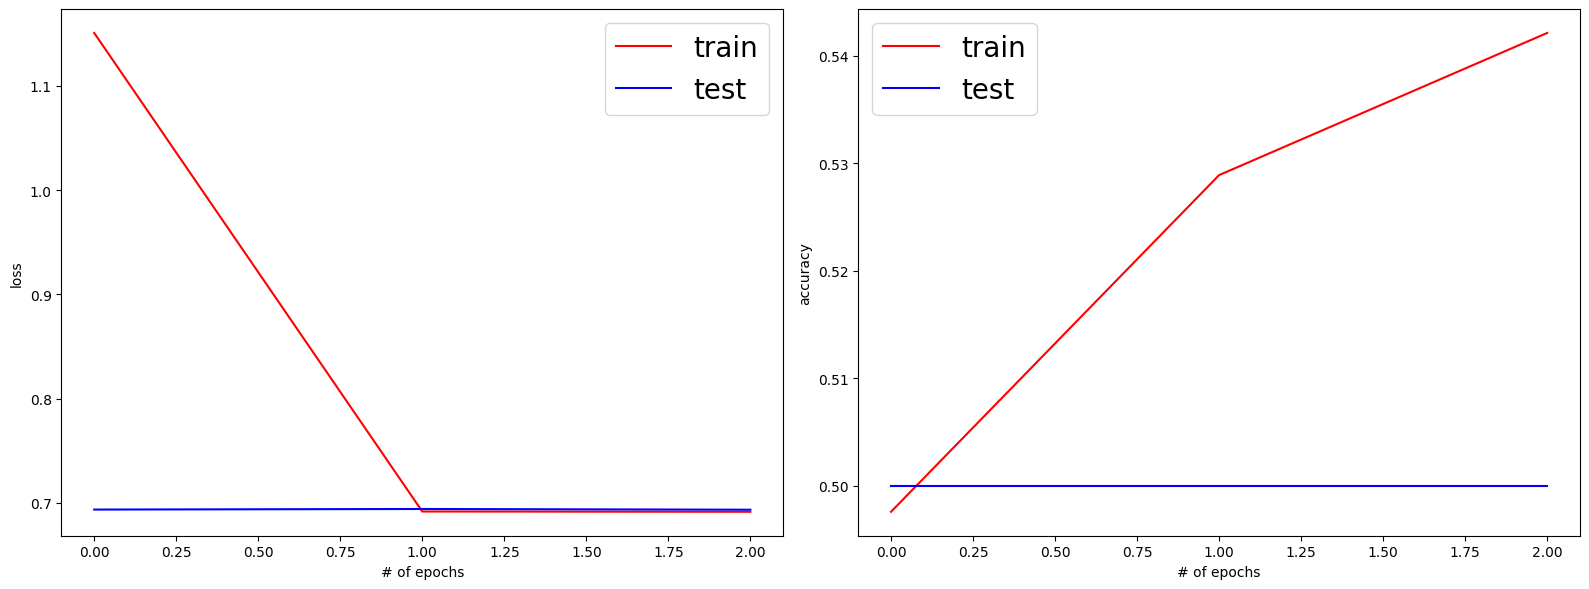

In [ ]:
plt.figure(figsize=(16,6))

plt.subplot(1,2,1)
nepochs = len(history.history['loss'])
plt.plot(range(nepochs), history.history['loss'], 'r-', label='train')
plt.plot(range(nepochs), history.history['val_loss'], 'b-', label='test')
plt.legend(prop={'size': 20})
plt.ylabel('loss')
plt.xlabel('# of epochs')

plt.subplot(1,2,2)
# Using 'accuracy' instead of 'acc'
plt.plot(range(nepochs), history.history['accuracy'], 'r-', label='train')
plt.plot(range(nepochs), history.history['val_accuracy'], 'b-', label='test')
plt.legend(prop={'size': 20})
plt.ylabel('accuracy')
plt.xlabel('# of epochs')

plt.tight_layout()
plt.show()

# Prediction
Now the model is trained so I used some real images and edited that image so that we can analysis model is working correcly or not.

In [ ]:
def ImagePrediction(loc):
    test_image = image.load_img(loc, target_size = (128,128))
    plt.axis('off')
    plt.imshow(test_image)
    test_image = image.img_to_array(test_image)
    test_image = np.expand_dims(test_image, axis =0)
    result = model.predict(test_image)
    if result[0][0] == 1:
        predictions = 'Real'
    else:
        predictions = 'Fake'
    print('Prediction: ',predictions)

Enter Location of Image to predict: /content/drive/MyDrive/real-and-fake-face-detection-master/dataset/face_pred/check.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
Prediction:  Real


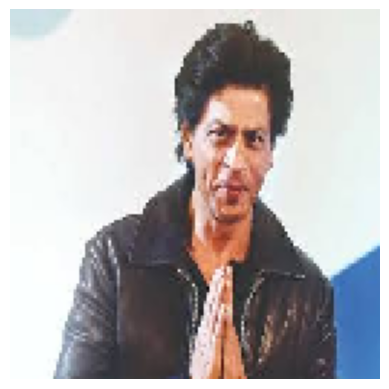

In [ ]:
img = input("Enter Location of Image to predict: ")
test_image_1 = ImagePrediction(img)

Enter Location of Image to predict: dataset/face_pred/check2.jpg
Prediction:  Fake


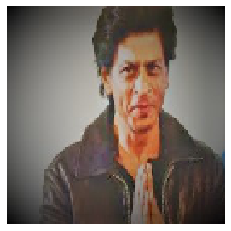

In [ ]:
img = input("Enter Location of Image to predict: ")
test_image_2 = ImagePrediction(img)

Enter Location of Image to predict: /content/drive/MyDrive/face_pred/check2.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Prediction:  Real


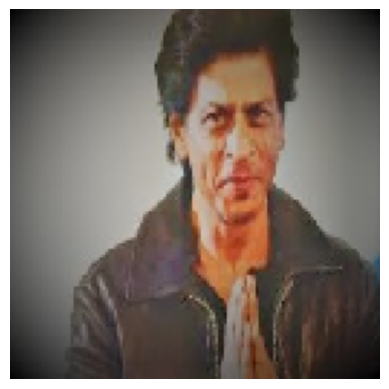

In [ ]:
img = input("Enter Location of Image to predict: ")
test_image_3 = ImagePrediction(img)

Enter Location of Image to predict: /content/drive/MyDrive/face_pred/check3.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
Prediction:  Real


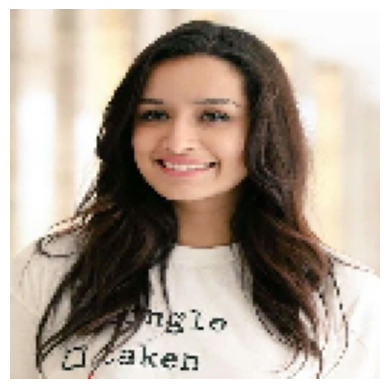

In [ ]:
img = input("Enter Location of Image to predict: ")
test_image_3 = ImagePrediction(img)